BUAN 6382 Applied Deep Learning Project

Cat Kim

Dataset: [Disease Detection Data](https://www.kaggle.com/datasets/bhadaneeraj/cardio-vascular-disease-detection)

# Setup

In [27]:
import warnings
import inspect
# Filter specific warnings if necessary (e.g., from libraries like sklearn or tf)
# warnings.filterwarnings('ignore')

print("--- Section: Setup ---")

# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os # Needed for file path joining
from io import StringIO # Needed for parsing text data as CSV

# Scikit-learn Libraries
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import boxcox
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay, f1_score, balanced_accuracy_score, recall_score
)


# TensorFlow Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import get as get_optimizer
from tensorflow.keras.metrics import Recall, Precision # Import Recall and Precision metrics
from tensorflow.keras.callbacks import EarlyStopping

# Kaggle Dataset Loading
# !pip install kagglehub
# !pip install kaggle # Sometimes needed depending on environment

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Explainability Libraries
# !pip install shap
# !pip install lime
import shap
import lime
import lime.lime_tabular


print("Setup complete. Libraries imported.")

--- Section: Setup ---
Setup complete. Libraries imported.


## Import data

In [2]:
# Define dataset reference and filename
dataset_reference = "bhadaneeraj/cardio-vascular-disease-detection"
dataset_filename = 'cardio_train.csv'

# Use dataset_download to get the local path to the dataset files
try:
    print(f"Attempting to download dataset: {dataset_reference}")
    path_to_downloaded_files = kagglehub.dataset_download(dataset_reference)
    print("Dataset files downloaded to:", path_to_downloaded_files)

    # Construct the full path to the CSV file
    csv_file_path = os.path.join(path_to_downloaded_files, dataset_filename)

    # Use pandas to read the CSV file from the downloaded path
    # The delimiter is ';' for this dataset
    print(f"Reading dataset from: {csv_file_path}")
    df = pd.read_csv(csv_file_path, delimiter=';')
    print("Dataset loaded successfully into pandas DataFrame.")

except Exception as e:
    print(f"Error loading dataset using kagglehub: {e}")
    # Fallback: If kagglehub fails, you might need a local copy or alternative method
    print("Please ensure you have internet access or the dataset files are available locally.")
    print("Cannot proceed without the dataset.")
    # In a real script, you might exit or raise an error here.
    df = None # Ensure df is None if loading failed


# Display the first few rows if data was loaded
if df is not None:
    print("\nDataset Head:")
    print(df.head())
else:
    print("DataFrame 'df' is not created due to loading failure.")

Attempting to download dataset: bhadaneeraj/cardio-vascular-disease-detection
Dataset files downloaded to: C:\Users\Veteran\.cache\kagglehub\datasets\bhadaneeraj\cardio-vascular-disease-detection\versions\1
Reading dataset from: C:\Users\Veteran\.cache\kagglehub\datasets\bhadaneeraj\cardio-vascular-disease-detection\versions\1\cardio_train.csv
Dataset loaded successfully into pandas DataFrame.

Dataset Head:
    id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  988  22469       1     155    69.0    130     80            2     2      0   
1  989  14648       1     163    71.0    110     70            1     1      0   
2  990  21901       1     165    70.0    120     80            1     1      0   
3  991  14549       2     165    85.0    120     80            1     1      1   
4  992  23393       1     155    62.0    120     80            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       1       0

# Data Pre-Processing

Prepare the dataset by handling missing values, encoding
categorical variables, and normalizing numerical features.


--- Section: Data Preprocessing ---
Dropped 'id' column. DataFrame shape: (69301, 12)
Initial Number of Records (from loaded file): 69301
Initial Number of Features (from loaded file): 13
Number of Duplicates before dropping: 24
Number of Missing Values: 0
Number of Records after dropping duplicates: 69277
Stored original feature names: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Top feature correlations with target:

age            0.238125
cholesterol    0.220723
weight         0.182033
gluc           0.089022
ap_lo          0.065288
ap_hi          0.054211
active        -0.035605
smoke         -0.015273
height        -0.011066
gender         0.008519
alco          -0.007253

✅ No features with correlation ≥ 0.8 to target 'cardio'.

Generating Correlation Plots...


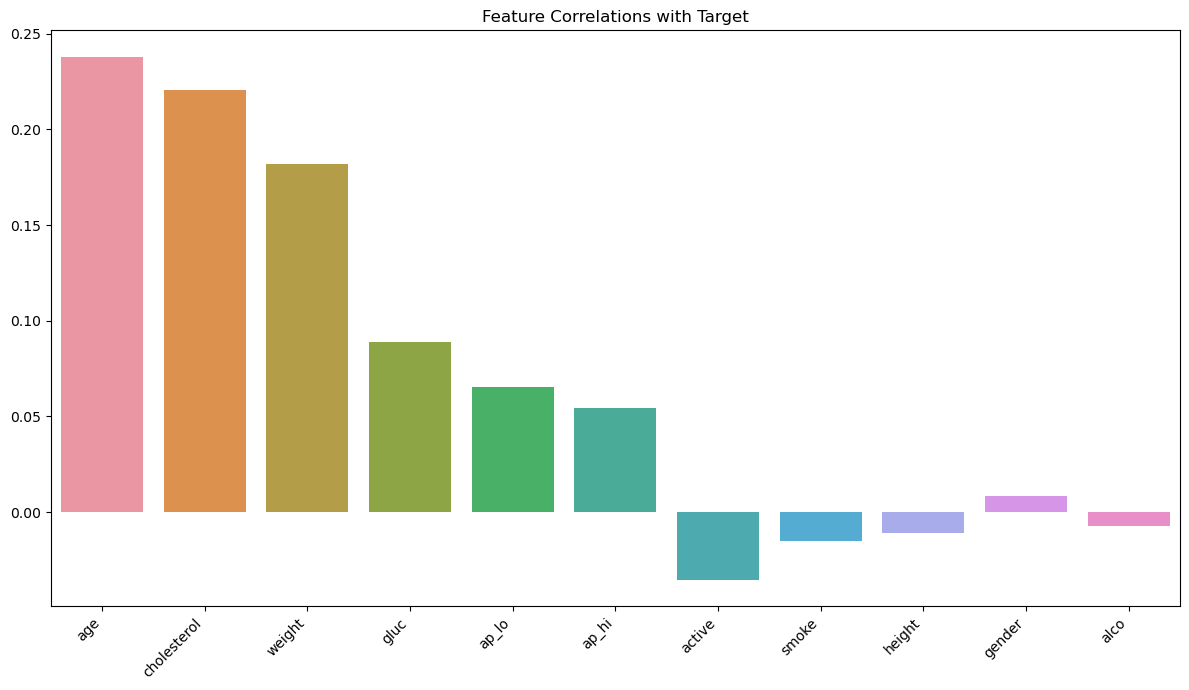

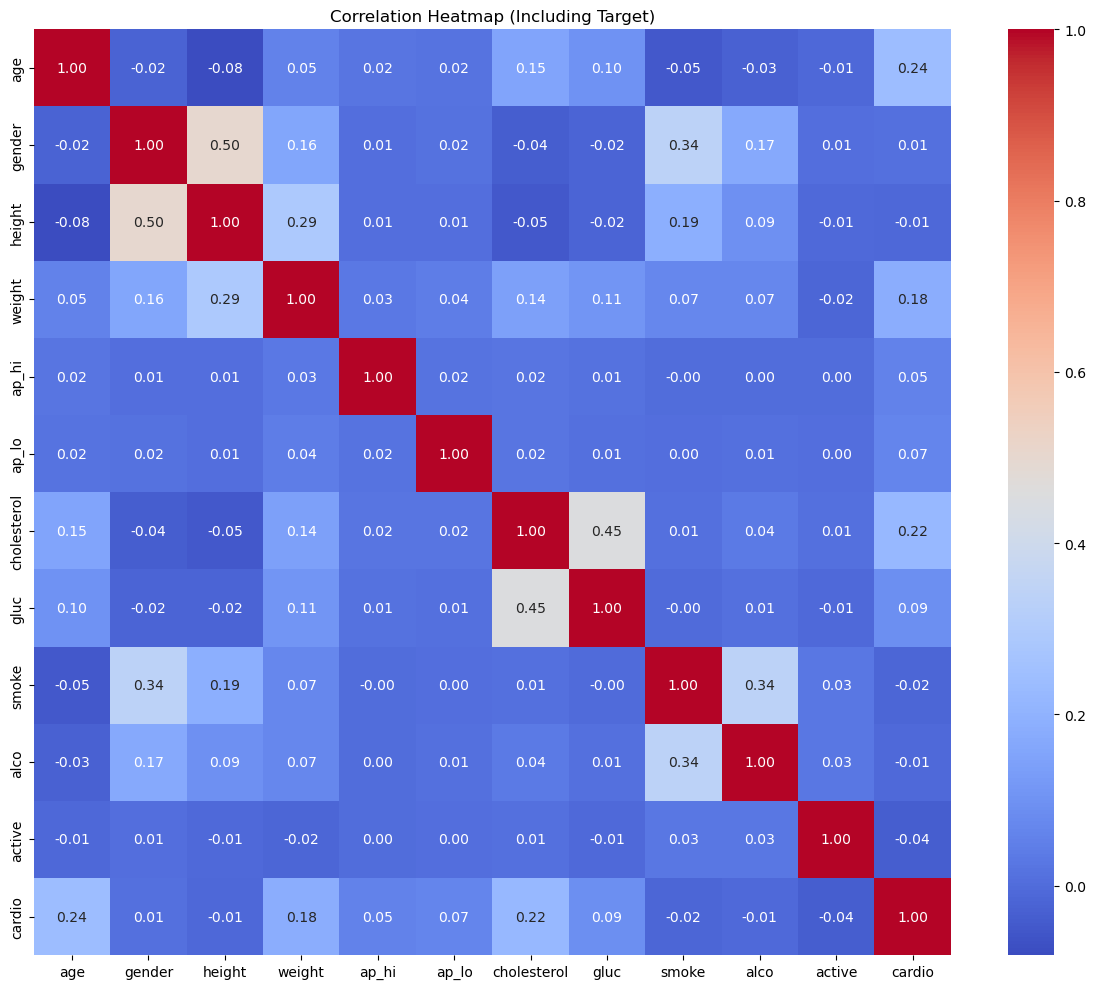


--- Feature Analysis: Types, Distributions, and Skewness ---

Summary Statistics (after dropping id and duplicates, before transformations):
                age        gender        height        weight         ap_hi         ap_lo   cholesterol          gluc         smoke          alco        active        cardio
count  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000  69277.000000
mean   19468.871415      1.349597    164.362140     74.205884    128.832787     96.656004      1.366933      1.226525      0.088081      0.053900      0.803975      0.499661
std     2467.386017      0.476846      8.206439     14.384935    154.802512    189.128722      0.680354      0.572330      0.283415      0.225821      0.396990      0.500003
min    10798.000000      1.000000     55.000000     10.000000   -150.000000    -70.000000      1.000000      1.000000      0.000000      0.000000      0.000000   

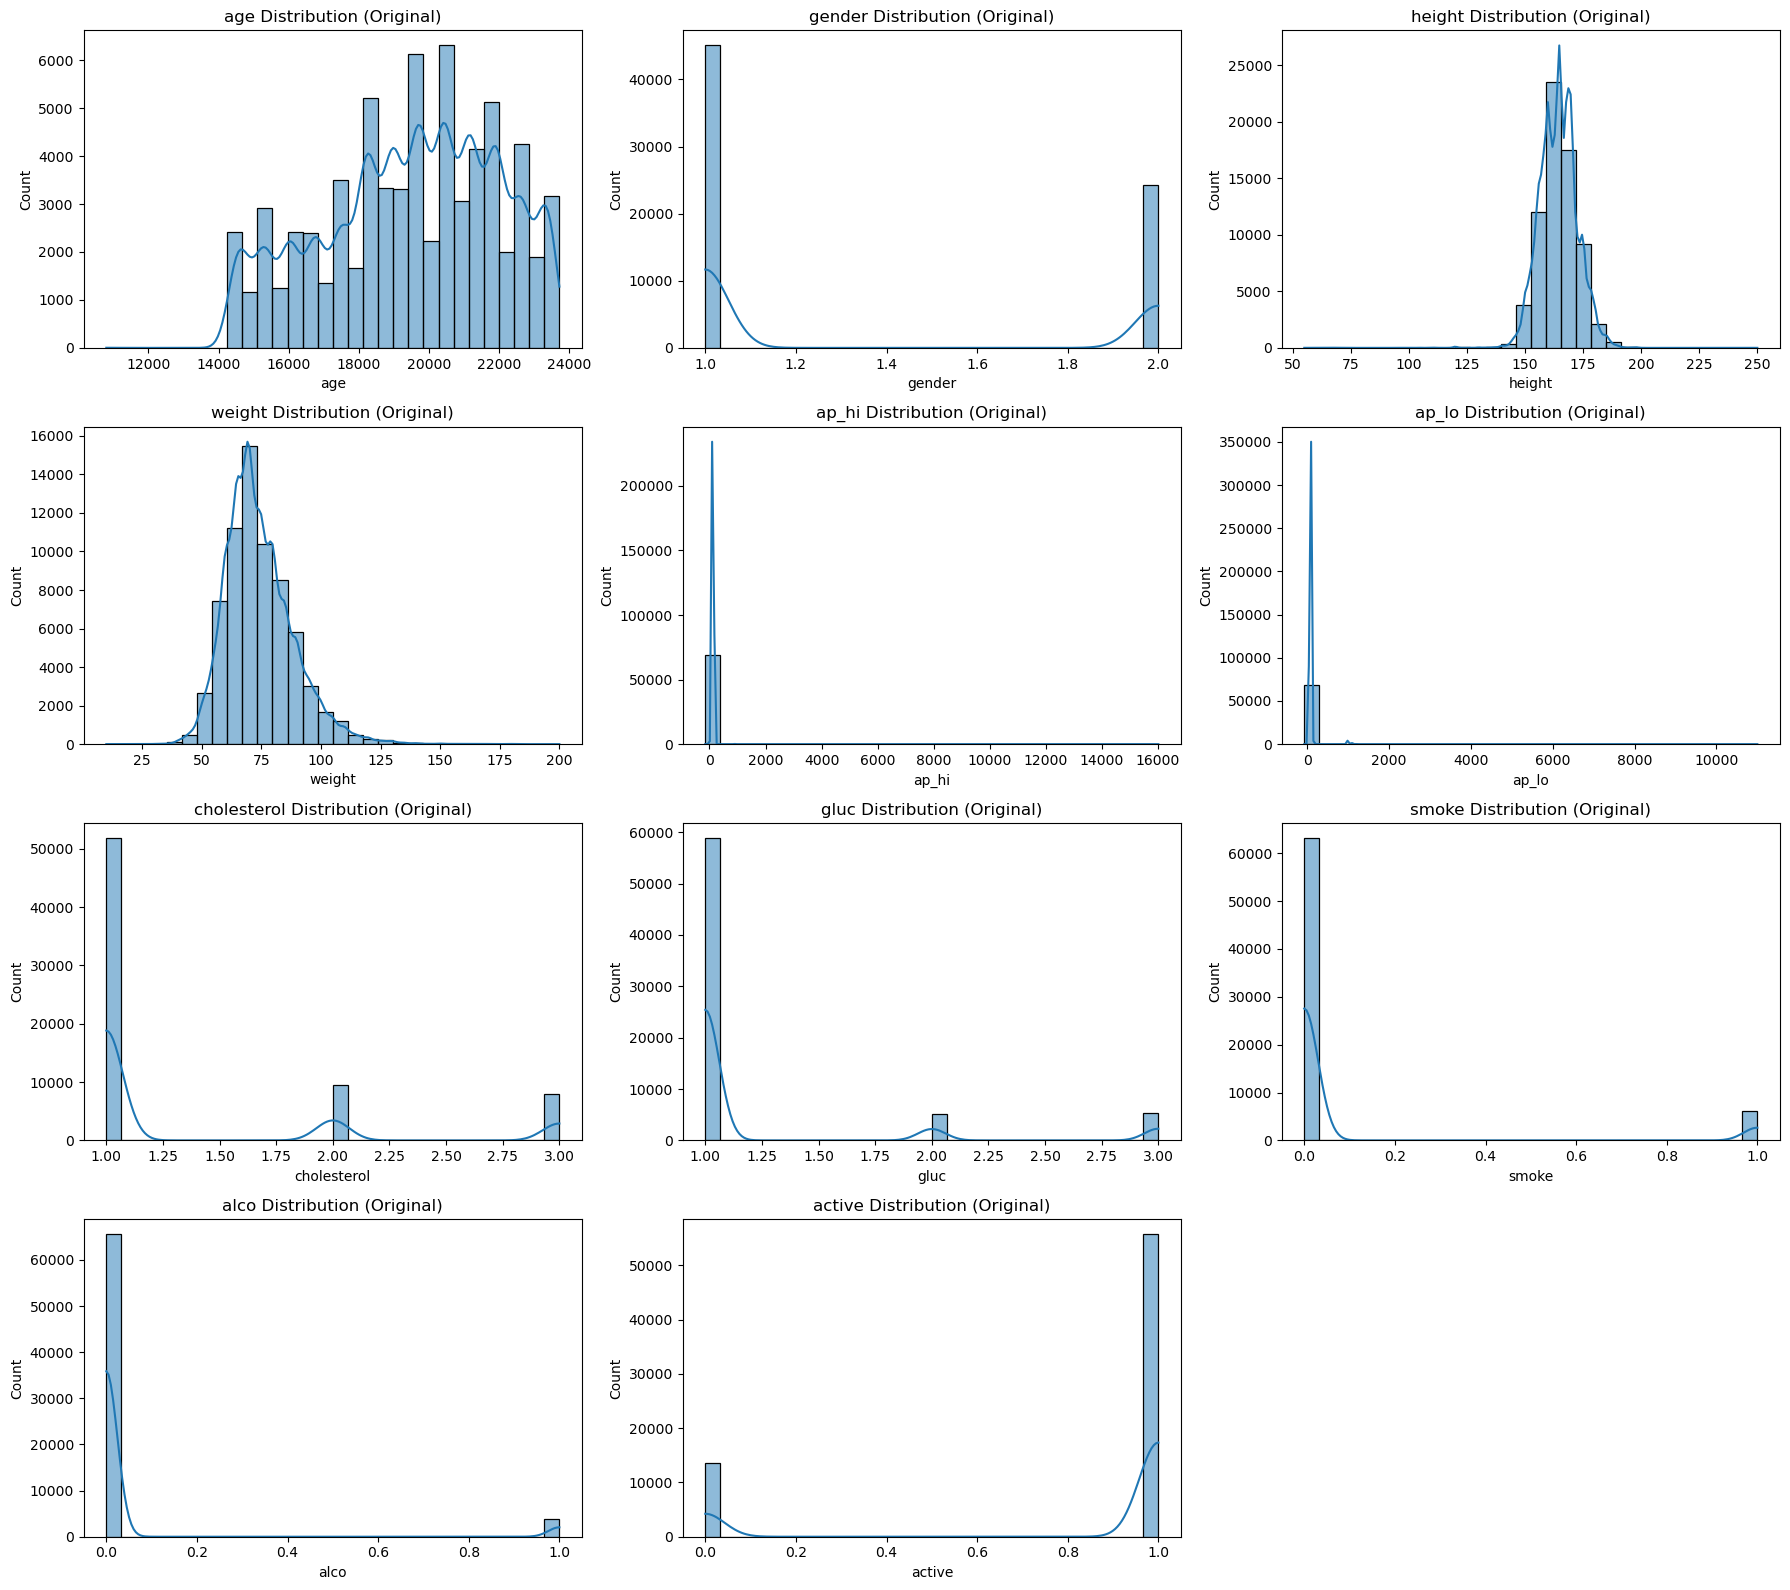


Calculating Skewness...

Skewness of Non-Binary Columns (Before Transformation):
ap_hi     84.871548
ap_lo     32.096031
weight     1.004679
age       -0.307408
height    -0.633994

Highly Skewed Features (|skew| > 1):
ap_hi     84.871548
ap_lo     32.096031
weight     1.004679

Applying Transformations to Highly Skewed Features Directly in df2...
Applied Box-Cox transformation and dropped original 'ap_hi' from df2.
Applied Box-Cox transformation and dropped original 'ap_lo' from df2.
Applied Log transformation and dropped original 'weight' from df2.

Skewness of Numerical Columns (After Transformation):
gluc            2.396910
cholesterol     1.586939
ap_hi_boxcox    1.181747
gender          0.630844
weight_log      0.215145
age            -0.307408
height         -0.633994
ap_lo_boxcox   -2.914357

Plotting Numerical Distributions After Transformation...


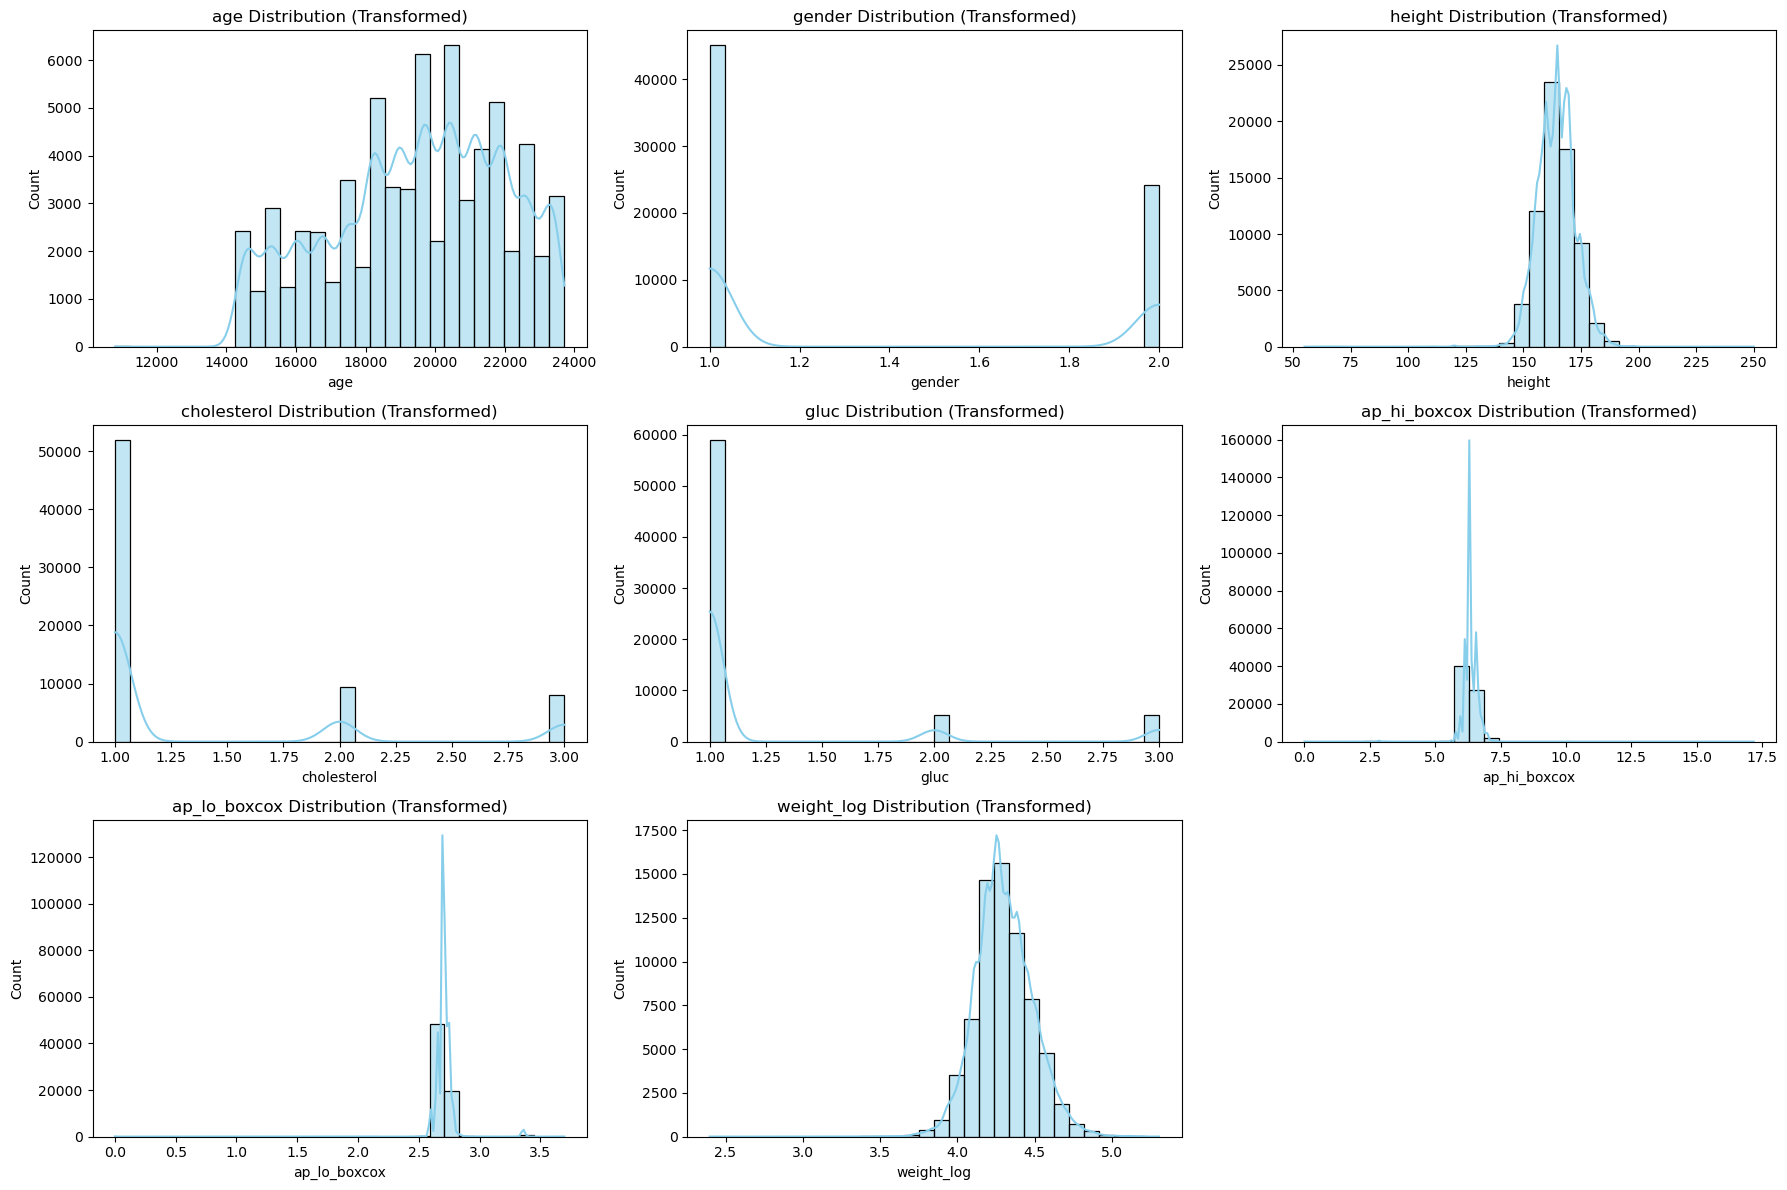


Analyzing Class Distribution...


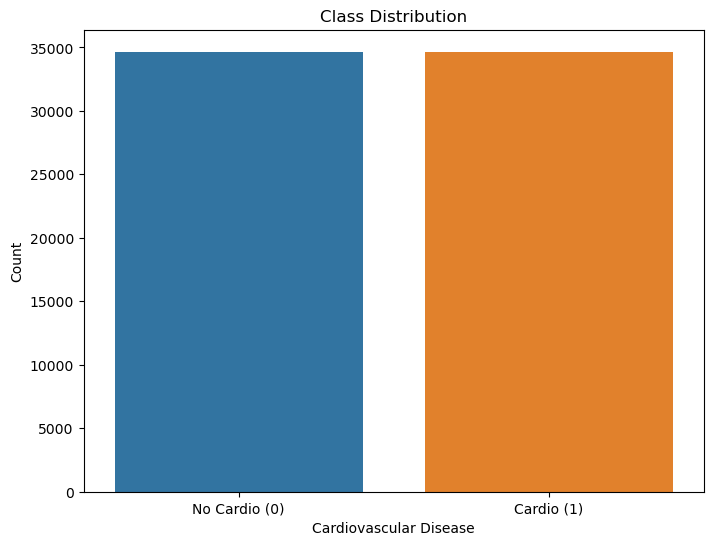

Class Distribution (Counts):
cardio
0    34662
1    34615

Class Distribution (%):
cardio
0    50.03
1    49.97

--- Data Splitting and Scaling ---
Splitting data into Training, Validation, and Test sets...
Training data shape: (41565, 11)
Validation data shape: (13856, 11)
Testing data shape: (13856, 11)
Number of final features after preprocessing and transformations: 11

Scaling numerical features...
Scaled 11 numerical features.
Input shape for the models: (11,)

Data Preprocessing complete.


In [5]:
# Proceed with preprocessing only if the DataFrame 'df' was successfully loaded
if df is not None:
    print("\n--- Section: Data Preprocessing ---")

    # Use a copy to avoid modifying the original df if df is needed elsewhere
    df2 = df.copy()

    # Drop the 'id' column as it's not a feature
    df2 = df2.drop('id',axis = 1)
    print(f"Dropped 'id' column. DataFrame shape: {df2.shape}")


    # Overview of data
    # Report initial counts from the original df before dropping 'id' and duplicates
    print(f"Initial Number of Records (from loaded file): {df.shape[0]}")
    print(f"Initial Number of Features (from loaded file): {df.shape[1]}")
    print(f"Number of Duplicates before dropping: {df2.duplicated().sum()}") # Check duplicates on df2 after dropping id
    print(f"Number of Missing Values: {df2.isnull().sum().sum()}")


    # Drop duplicates
    df2.drop_duplicates(inplace=True)
    print("Number of Records after dropping duplicates:", df2.shape[0])


    # --- Initial Split of features (X) and target (y) for correlation/analysis ---
    # We split here to get X (features only) for some initial analysis and to store original names
    X_initial = df2.drop('cardio', axis=1)
    y = df2['cardio']

    # Store original feature names before transformation/scaling for SHAP/LIME later
    original_feature_names = X_initial.columns.tolist()
    print(f"Stored original feature names: {original_feature_names}")


    """## Target leakage detection / correlation"""
    # Using X_initial and y here for initial correlation checks
    target_col_name = 'cardio'
    correlation_threshold = 0.8


    # Combine X_initial and y temporarily for correlation matrix calculation
    df_for_corr = X_initial.copy()
    df_for_corr[target_col_name] = y

    # Compute correlations
    correlations = df_for_corr.corr()
    target_corr = correlations[target_col_name].drop(target_col_name) # exclude self-correlation
    target_corr_sorted = target_corr.sort_values(key=abs, ascending=False)

    # Print top correlations
    print("\nTop feature correlations with target:\n")
    # Use to_string() for potentially long lists
    print(target_corr_sorted.to_string())


    # Flag high correlation (possible leakage)
    high_corr = target_corr[abs(target_corr) >= correlation_threshold]
    if not high_corr.empty:
        print(f"\n🚨 Variables with correlation ≥ {correlation_threshold} to target '{target_col_name}':")
        for var, corr in high_corr.items():
            print(f"  • {var:<25} → Corr = {corr:.3f}")
    else:
        print(f"\n✅ No features with correlation ≥ {correlation_threshold} to target '{target_col_name}'.")

    # Plot Feature Correlations with Target
    print("\nGenerating Correlation Plots...")
    plt.figure(figsize=(12, 7))
    sns.barplot(x=target_corr_sorted.index, y=target_corr_sorted.values)
    plt.title('Feature Correlations with Target')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    # Correlation heatmap - using df_for_corr
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_for_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap (Including Target)')
    plt.tight_layout()
    plt.show()


    """## Feature Analysis: Types, Distributions, and Skewness""" # Updated Heading

    print("\n--- Feature Analysis: Types, Distributions, and Skewness ---")

    # --- Add df2.describe() here before identifying types and transforming ---
    # Using df2 which has 'id' dropped and duplicates removed
    print("\nSummary Statistics (after dropping id and duplicates, before transformations):")
    print(df2.describe().to_string())


    # --- Identify Feature Types ---
    # These lists will help identify which columns to transform or scale.
    # They are based on df2 which includes the target temporarily for type identification printout.
    binary_cols = []
    categorical_cols = []
    non_binary_cols = [] # This will contain numerical columns

    # Print Feature Types in the exact format requested
    # This loop iterates through all columns in df2 (including the target 'cardio')
    # to print the type in the exact format from the image.
    print("\nFeature Types:") # Heading matches image implied heading

    for col in df2.columns:
        col_type = "Unknown" # Default type
        unique_vals = set(df2[col].dropna().unique()) # Check unique values on df2

        if col == 'cardio':
             col_type = "Binary" # Explicitly set for the target column
        elif unique_vals <= {0, 1}:
            col_type = "Binary"
            binary_cols.append(col) # Add to list if it's a feature
        elif df2[col].dtype in [int, 'int64', 'int32'] and len(unique_vals) <= 10:
             col_type = "Categorical"
             categorical_cols.append(col) # Add to list if it's a feature
        else:
             col_type = "Non-binary" # Match image output exactly
             non_binary_cols.append(col) # Add to list if it's a feature

        # Print in the exact format requested: "column_name: Type"
        print(f"{col}: {col_type}")

    # The lists binary_cols, categorical_cols, and non_binary_cols now contain only feature names


    # --- Plot original feature distributions ---
    # Using X_initial here (features after dropping 'id' and duplicates)
    print("\nPlotting Original Feature Distributions...")
    all_feature_cols_initial = X_initial.columns # Use X_initial for plotting original distributions
    num_feature_cols_initial = len(all_feature_cols_initial)
    cols_per_row_initial = 3
    rows_needed_initial = (num_feature_cols_initial + cols_per_row_initial - 1) // cols_per_row_initial # Ceiling division

    plt.figure(figsize=(6 * cols_per_row_initial, 4 * rows_needed_initial))

    for i, col in enumerate(all_feature_cols_initial):
        plt.subplot(rows_needed_initial, cols_per_row_initial, i + 1)
        sns.histplot(X_initial[col], kde=True, bins=30, edgecolor='black')
        plt.title(f'{col} Distribution (Original)')
        plt.xlabel(col)
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()


    # --- Calculate Skewness for non-binary columns ---
    # Using non_binary_cols identified above (feature columns only)
    if non_binary_cols:
        print("\nCalculating Skewness...")
        # Select only non-binary feature columns from df2 for skewness calculation
        non_binary_df2_for_skew = df2[non_binary_cols]
        skewness = non_binary_df2_for_skew.skew().sort_values(ascending=False)
        print("\nSkewness of Non-Binary Columns (Before Transformation):")
        print(skewness.to_string())

        # Identify highly skewed variables (absolute skew > 1) - decide based on this printout
        high_skew_vars = skewness[abs(skewness) > 1.0]
        print("\nHighly Skewed Features (|skew| > 1):")
        print(high_skew_vars.to_string())


        # --- Apply transformations to highly skewed non-binary variables directly in df2 ---
        print("\nApplying Transformations to Highly Skewed Features Directly in df2...")
        # Box-Cox: applied to positive values. Handle potential zeros/negatives if necessary.
        # For ap_hi and ap_lo, values are expected to be >= 1.
        # Only transform if the column exists in df2 and was identified as highly skewed
        for col in ['ap_hi', 'ap_lo']:
             if col in df2.columns and col in high_skew_vars.index:
                 try:
                     # Check if column contains non-positive values before Box-Cox
                     if (df2[col] <= 0).any():
                          print(f"Warning: Column '{col}' contains non-positive values. Clipping to 1 for Box-Cox.")
                          df2[f'{col}_boxcox'], _ = boxcox(df2[col].clip(lower=1)) # Add new transformed column to df2
                     else:
                          df2[f'{col}_boxcox'], _ = boxcox(df2[col]) # Add new transformed column to df2
                     df2 = df2.drop(col, axis=1) # Drop original column from df2
                     print(f"Applied Box-Cox transformation and dropped original '{col}' from df2.")
                 except Exception as e:
                     print(f"Could not apply Box-Cox to '{col}': {e}")
                     print(f"Original '{col}' column retained in df2.")


        # Log-transform weight (mild skew, based on previous analysis, check if in high_skew_vars)
        # Only transform if 'weight' exists in df2 and was identified as highly skewed
        if 'weight' in df2.columns and 'weight' in high_skew_vars.index:
            try:
                df2['weight_log'] = np.log1p(df2['weight']) # np.log1p handles zero safely # Add new transformed column to df2
                df2 = df2.drop('weight', axis=1) # Drop original column from df2
                print("Applied Log transformation and dropped original 'weight' from df2.")
            except Exception as e:
                 print(f"Could not apply Log transformation to 'weight': {e}")
                 print("'weight' column retained in df2.")

        # --- Recalculate skew after transformations ---
        # Identify numerical columns *after* transformations in df2
        numerical_cols_after_transform = df2.select_dtypes(include=np.number).columns.tolist()
        # Exclude binary columns from skewness check again if they are numerical (e.g., 0/1 ints)
        # Also exclude 'cardio' from skewness check if it's numerical (0/1)
        numerical_for_skew_check_after = [col for col in numerical_cols_after_transform if col not in binary_cols and col != 'cardio']


        if numerical_for_skew_check_after:
             skewness_after = df2[numerical_for_skew_check_after].skew().sort_values(ascending=False)
             print("\nSkewness of Numerical Columns (After Transformation):")
             print(skewness_after.to_string())
        else:
             print("\nNo numerical columns found to check skewness after transformation.")


        # --- Plot numerical distributions AFTER transformation ---
        # Plot only numerical features after transformation from df2
        print("\nPlotting Numerical Distributions After Transformation...")
        if numerical_for_skew_check_after: # Plot only numerical features after transformation
            num_cols_after_transform_features = len(numerical_for_skew_check_after)
            cols_per_row_after = 3
            rows_needed_after = (num_cols_after_transform_features + cols_per_row_after - 1) // cols_per_row_after

            plt.figure(figsize=(6 * cols_per_row_after, 4 * rows_needed_after))

            for i, col in enumerate(numerical_for_skew_check_after): # Iterate through numerical features
                plt.subplot(rows_needed_after, cols_per_row_after, i + 1)
                sns.histplot(df2[col], kde=True, bins=30, color='skyblue', edgecolor='black')
                plt.title(f'{col} Distribution (Transformed)')
                plt.xlabel(col)
                plt.ylabel('Count')

            plt.tight_layout()
            plt.show()
        else:
            print("No numerical columns found to plot after transformation.")

    else:
         print("\nNo non-binary columns found to check/transform skewness.")


    """## EDA: Class Distribution"""
    # The class distribution plot and prints are appropriate for EDA
    print("\nAnalyzing Class Distribution...")
    # Use the original y for class distribution plot and counts
    plt.figure(figsize=(8, 6))
    sns.countplot(x=y) # Plot using the target series y
    plt.title('Class Distribution')
    plt.xlabel('Cardiovascular Disease')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['No Cardio (0)', 'Cardio (1)']) # Label ticks
    plt.show()

    # Print class distribution (raw count & percentage)
    print("Class Distribution (Counts):")
    print(y.value_counts().to_string())

    print("\nClass Distribution (%):")
    print(y.value_counts(normalize=True).mul(100).round(2).to_string())


    """## Data Splitting and Scaling""" # Updated Heading
    print("\n--- Data Splitting and Scaling ---")

    # --- Split the data AFTER all preprocessing and transformations on df2 are complete ---
    # Now X will be derived from df2 *after* transformations
    print("Splitting data into Training, Validation, and Test sets...")

    # Define X and y *after* transformations have been applied to df2
    # X is the features, y is the target
    X_final = df2.drop('cardio', axis=1) # X_final now contains transformed features
    y_final = df2['cardio'] # y_final is the target

    # Store the final feature names after transformations (these are the column names of X_final)
    final_feature_names = X_final.columns.tolist()


    # Ensure y_final is a numpy array if it's not already, which helps with stratify
    if isinstance(y_final, pd.Series): # Check if it's a pandas Series
        y_final_np = y_final.values
    else: # Assume it's already a numpy array or similar
        y_final_np = y_final

    # 80% train+val, 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split( # Use X_final and y_final_np
        X_final, y_final_np, test_size=0.2, stratify=y_final_np, random_state=42
    )
    # Split train_val into 75% train (60% of original) and 25% val (20% of original)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42 # Use 0.25 of the 80% to get 20% for val
    )


    print(f"Training data shape: {X_train.shape}")
    print(f"Validation data shape: {X_val.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Number of final features after preprocessing and transformations: {X_train.shape[1]}") # Should be 11


    # --- Feature scaling AFTER splitting to prevent data leakage ---
    print("\nScaling numerical features...")
    scaler = StandardScaler()

    # Identify numerical columns *after* transformations to scale only them
    # Use the columns from the split dataframes X_train to be safe
    numerical_cols_to_scale = X_train.select_dtypes(include=np.number).columns.tolist()

    if numerical_cols_to_scale:
        # Fit the scaler only on the training data for the numerical columns and transform all sets
        X_train_scaled = X_train.copy() # Start with copies to avoid modifying original splits
        X_val_scaled = X_val.copy()
        X_test_scaled = X_test.copy()

        # Apply scaling only to the identified numerical columns
        X_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
        X_val_scaled[numerical_cols_to_scale] = scaler.transform(X_val[numerical_cols_to_scale])
        X_test_scaled[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

        # Convert scaled DataFrames back to numpy arrays for TensorFlow input
        # TensorFlow typically works better with numpy arrays
        X_train_scaled_np = X_train_scaled.values
        X_val_scaled_np = X_val_scaled.values
        X_test_scaled_np = X_test_scaled.values

        print(f"Scaled {len(numerical_cols_to_scale)} numerical features.")

    else:
        print("No numerical columns found to scale.")
        # If no numerical columns, convert the dataframes (containing only binary/categorical) to numpy arrays
        X_train_scaled_np = X_train.values
        X_val_scaled_np = X_val.values
        X_test_scaled_np = X_test.values


    # Get the number of features for the input layer from the scaled training data (numpy array)
    input_shape = (X_train_scaled_np.shape[1],)
    print(f"Input shape for the models: {input_shape}")

    print("\nData Preprocessing complete.")

else:
    print("\nSkipping Data Preprocessing as data was not loaded.")

In [7]:
df2.head()

,age,gender,height,cholesterol,gluc,smoke,alco,active,cardio,ap_hi_boxcox,ap_lo_boxcox,weight_log
0,22469,1,155,2,2,0,0,1,0,6.421055,2.701456,4.248495
1,14648,1,163,1,1,0,0,1,1,6.139645,2.654450,4.276666
2,21901,1,165,1,1,0,0,1,0,6.285580,2.701456,4.262680
3,14549,2,165,1,1,1,1,1,0,6.285580,2.701456,4.454347
4,23393,1,155,1,1,0,0,1,0,6.285580,2.701456,4.143135


# Building Models & Training

Design a feedforward neural network. Specify the architecture and hyperparameters used.

In [9]:
# Proceed only if preprocessing was successful and scaled data exists
if 'X_train_scaled_np' in locals() and X_train_scaled_np is not None:

    print("\n--- Section: Model Comparison and Training ---")

    # --- Define Different Model Configurations to Compare ---
    # Define configurations with varying layers, neurons, dropout, optimizer, learning rate, batch size, patience
    # These are examples; you should experiment with different values
    model_configs = [
        {
            'name': 'Model_1_Simple_1_Layer_Adam',
            'layer_specs': [16], # One hidden layer with 16 neurons
            'dropout_rate': 0.1,
            'optimizer': 'adam',
            'learning_rate': 0.001, # Default Adam LR
            'epochs': 100, # Use Early Stopping, set high max epochs
            'batch_size': 32,
            'patience': 10 # Early Stopping patience
        },
        {
            'name': 'Model_2_Current_2_Layers_Adam',
            'layer_specs': [64, 32], # Two hidden layers with 64 and 32 neurons
            'dropout_rate': 0.2,
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'epochs': 100,
            'batch_size': 32,
            'patience': 10
        },
        {
            'name': 'Model_3_More_Complex_3_Layers_Adam',
            'layer_specs': [128, 64, 32], # Three hidden layers
            'dropout_rate': 0.3,
            'optimizer': 'adam',
            'learning_rate': 0.0005, # Slightly lower LR for more complex model
            'epochs': 150, # Might need more epochs for complex models
            'batch_size': 64, # Try a different batch size
            'patience': 15 # More patience for complex models
        },
         {
            'name': 'Model_4_2_Layers_SGD', # Example using a different optimizer
            'layer_specs': [64, 32],
            'dropout_rate': 0.2,
            'optimizer': 'sgd', # Stochastic Gradient Descent
            'learning_rate': 0.01, # SGD often uses higher LRs
            'epochs': 100,
            'batch_size': 32,
            'patience': 10
        },
         {
            'name': 'Model_5_2_Layers_Adam_Lower_Dropout', # Example with lower dropout
            'layer_specs': [64, 32],
            'dropout_rate': 0.1, # Lower dropout
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'epochs': 100,
            'batch_size': 32,
            'patience': 10
        }
    ]

    # List to store evaluation results for each model
    model_comparison_results = []
    # --- List to store training history for each model ---
    all_model_histories = []


    # --- Loop Through Configurations, Build, Train, and Evaluate Models ---

    for config in model_configs:
        print(f"\n--- Training Model: {config['name']} ---")

        # Clear previous model from memory to avoid interference
        tf.keras.backend.clear_session()

        # Build the model based on the current configuration
        model = Sequential(name=config['name'])

        # --- ADD tf.keras.Input layer as the first layer ---
        # This addresses the UserWarning about input_shape
        model.add(tf.keras.Input(shape=input_shape))

        # First hidden layer - DO NOT include input_shape here anymore
        model.add(Dense(units=config['layer_specs'][0], activation='relu'))

        # Add dropout after the first hidden layer if specified and applicable
        if config['dropout_rate'] > 0:
             model.add(Dropout(config['dropout_rate']))

        # Additional hidden layers (start from the second layer spec)
        for units in config['layer_specs'][1:]:
            model.add(Dense(units=units, activation='relu'))
            # Add dropout after subsequent hidden layers
            if config['dropout_rate'] > 0:
                model.add(Dropout(config['dropout_rate']))

        # Output layer
        model.add(Dense(units=1, activation='sigmoid'))

        # Compile the model with the specified optimizer and learning rate
        optimizer_instance = get_optimizer({'class_name': config['optimizer'], 'config': {'learning_rate': config['learning_rate']}})

        # Include Accuracy, Recall and Precision as Keras metrics to track during training history
        model.compile(optimizer=optimizer_instance,
                      loss='binary_crossentropy',
                      metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]) # Give names for history


        # Define Early Stopping for this model configuration
        early_stopping = EarlyStopping(monitor='val_loss', patience=config['patience'], restore_best_weights=True)

        # Train the model
        print(f"Starting training for {config['name']} (Batch Size: {config['batch_size']}, LR: {config['learning_rate']}, Patience: {config['patience']})...")
        start_time = time.time()
        # --- Store the history object for this model ---
        history = model.fit(X_train_scaled_np, y_train, # Use numpy arrays for training
                            epochs=config['epochs'],
                            batch_size=config['batch_size'],
                            validation_data=(X_val_scaled_np, y_val), # Use numpy arrays for validation
                            callbacks=[early_stopping],
                            verbose=0) # Set verbose=0 to reduce output during training
        # --- Append history to the list ---
        all_model_histories.append({'name': config['name'], 'history': history})


        end_time = time.time()
        training_time = end_time - start_time
        epochs_ran = len(history.history['loss']) # Actual epochs run due to Early Stopping
        print(f"Training finished for {config['name']} in {training_time:.2f} seconds. Ran for {epochs_ran} epochs.")


        # Evaluate the model on the test set
        print(f"Evaluating {config['name']} on the test set...")
        # model.evaluate returns [loss, accuracy, recall_metric, precision_metric] based on compile metrics
        results_eval = model.evaluate(X_test_scaled_np, y_test, verbose=0) # Use numpy arrays for evaluation


        # Get predicted probabilities and binary predictions for other metrics (F1, Balanced Accuracy, AUC)
        y_pred_prob = model.predict(X_test_scaled_np) # Use numpy array for prediction
        y_pred = (y_pred_prob > 0.5).astype("int32") # Default threshold 0.5

        # Calculate additional metrics manually using y_test and y_pred
        y_test_np = y_test # y_test should already be a numpy array from train_test_split

        f1 = f1_score(y_test_np, y_pred)
        balanced_acc = balanced_accuracy_score(y_test_np, y_pred)
        recall_manual = recall_score(y_test_np, y_pred)
        precision_manual = precision_score(y_test_np, y_pred)
        roc_auc = roc_auc_score(y_test_np, y_pred_prob) # AUC requires probabilities


        # Store the configuration and evaluation results
        model_results = {
            'Model': config['name'],
            'Layers': len(config['layer_specs']),
            'Neurons': str(config['layer_specs']),
            'Dropout Rate': config['dropout_rate'],
            'Optimizer': config['optimizer'],
            'Learning Rate': config['learning_rate'],
            'Batch Size': config['batch_size'],
            'Epochs Ran': epochs_ran,
            'Training Time (s)': training_time,
            'Test Loss': results_eval[0],
            'Test Accuracy': results_eval[1],
            'Test Recall (Metric)': results_eval[2], # Recall from Keras metric during evaluate
            'Test Precision (Metric)': results_eval[3], # Precision from Keras metric during evaluate
            'Test F1 Score (Manual)': f1, # Calculated manually from y_pred (0.5 threshold)
            'Test Balanced Accuracy (Manual)': balanced_acc, # Calculated manually from y_pred (0.5 threshold)
            'Test Recall (Manual)': recall_manual, # Calculated manually from y_pred (0.5 threshold)
            'Test Precision (Manual)': precision_manual, # Calculated manually from y_pred (0.5 threshold)
            'Test AUC': roc_auc # Calculated from probabilities
        }
        model_comparison_results.append(model_results)

        print(f"Evaluation metrics calculated for {config['name']}.")
        print("-" * 30)

    # --- Plot Training History for All Compared Models ---
    print("\n--- Plotting Training History for All Models ---")

    # Ensure matplotlib is imported if not already at the top
    import matplotlib.pyplot as plt

    # all_model_histories is a list containing dictionaries like {'name': model_name, 'history': history_object}
    if all_model_histories:
        for model_history_data in all_model_histories:
            model_name = model_history_data['name']
            history = model_history_data['history'] # This is the History object from model.fit()

            # Check if history object exists and has data (e.g., after early stopping)
            if history and history.history:
                print(f"Generating history plot for: {model_name}")
                plt.figure(figsize=(12, 5)) # Create a new figure for each model

                # Plot Loss over Epochs
                plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
                plt.plot(history.history['loss'], label='Training Loss')
                # Check if validation loss is available
                if 'val_loss' in history.history:
                    plt.plot(history.history['val_loss'], label='Validation Loss')
                plt.title(f'{model_name}: Loss over Epochs') # Add model name to title
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                plt.legend()
                plt.grid(True)

                # Plot Accuracy over Epochs
                plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
                plt.plot(history.history['accuracy'], label='Training Accuracy')
                # Check if validation accuracy is available
                if 'val_accuracy' in history.history:
                    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

                plt.title(f'{model_name}: Accuracy over Epochs') # Add model name to title
                plt.xlabel('Epoch')
                plt.ylabel('Accuracy')
                plt.legend()
                plt.grid(True)

                plt.tight_layout() # Adjust layout to prevent titles/labels overlapping
                plt.show() # Display plot for this model
            else:
                 print(f"Training history not available or empty for {model_name} to plot.")
    else:
        print("No model histories were stored for plotting.")


else:
    print("\nSkipping Model Comparison and Training as data was not loaded/preprocessed.")


--- Section: Model Comparison and Training ---

--- Training Model: Model_1_Simple_1_Layer_Adam ---

Starting training for Model_1_Simple_1_Layer_Adam (Batch Size: 32, LR: 0.001, Patience: 10)...
Training finished for Model_1_Simple_1_Layer_Adam in 520.30 seconds. Ran for 59 epochs.
Evaluating Model_1_Simple_1_Layer_Adam on the test set...
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Evaluation metrics calculated for Model_1_Simple_1_Layer_Adam.
------------------------------

--- Training Model: Model_2_Current_2_Layers_Adam ---
Starting training for Model_2_Current_2_Layers_Adam (Batch Size: 32, LR: 0.001, Patience: 10)...
Training finished for Model_2_Current_2_Layers_Adam in 397.77 seconds. Ran for 38 epochs.
Evaluating Model_2_Current_2_Layers_Adam on the test set...
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Evaluation metrics calculated for Model_2_Current_2_Layers_Adam.
------------------------------

--- Training Model: Model_3_More_Complex_3_Layers_Adam ---
Starting training for M

# Model Evaluation


--- Section: Model Comparison Results ---

Generating Model Comparison Plots...


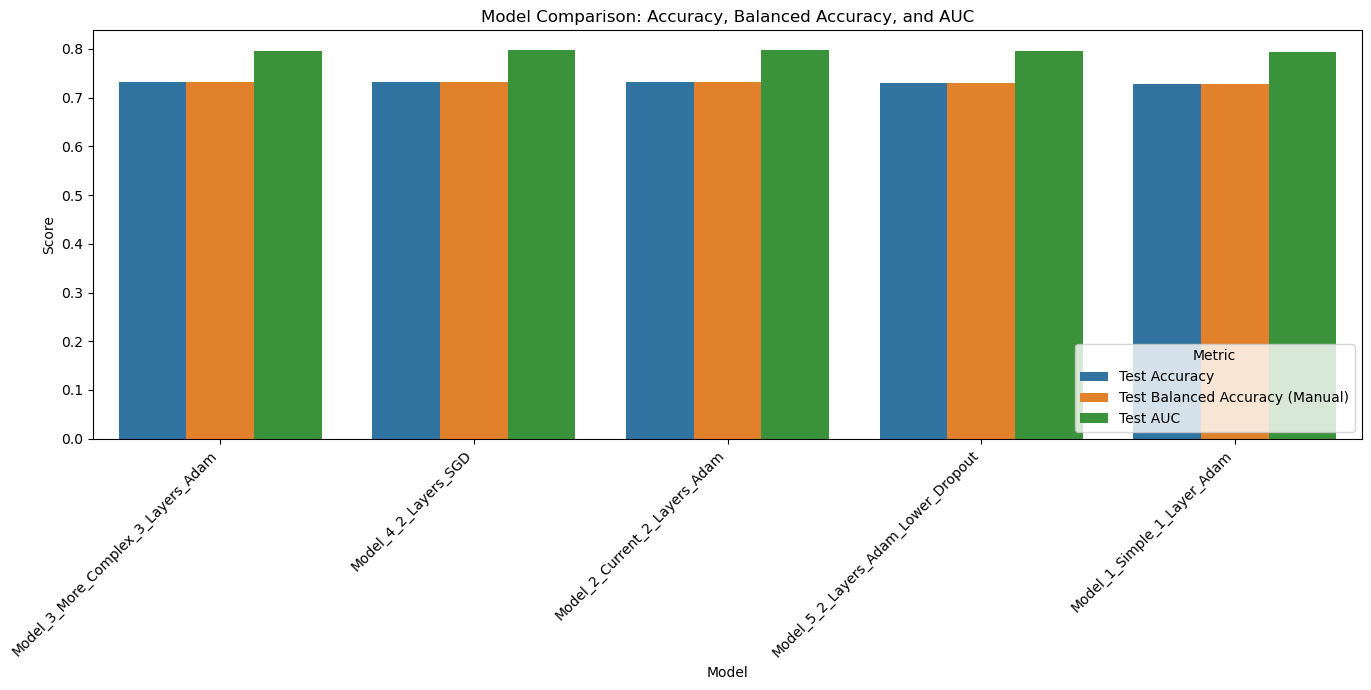

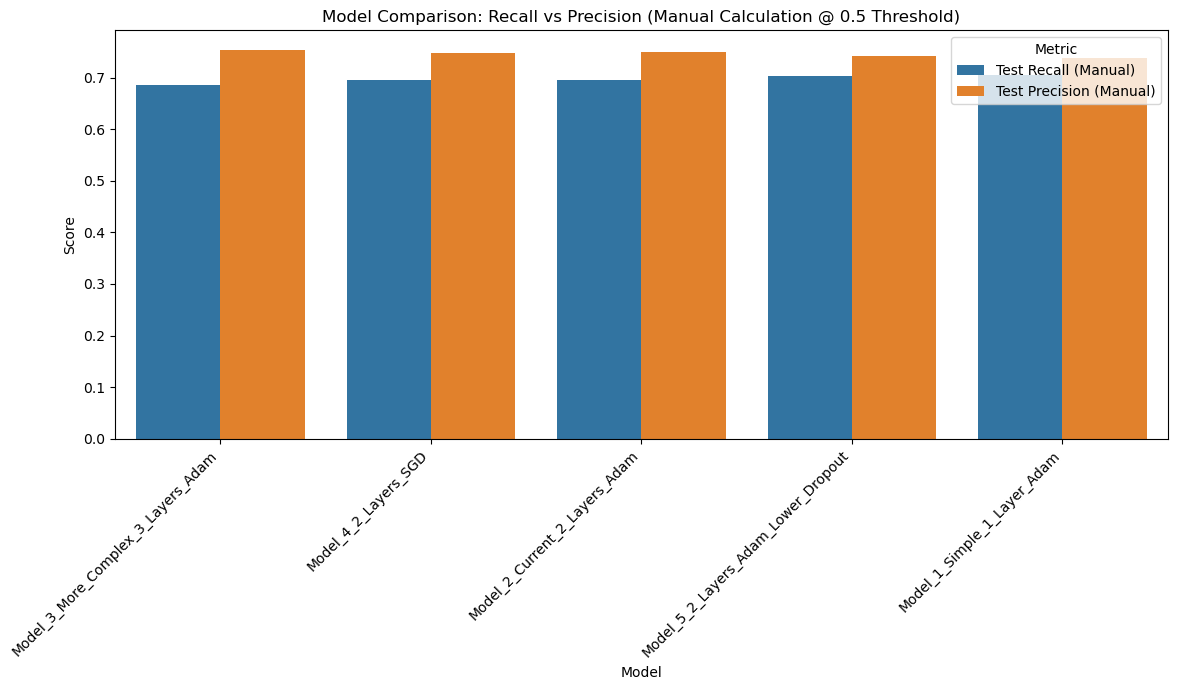


Model Comparison Results presented.


In [19]:
# Proceed only if comparison results exist
if 'model_comparison_results' in locals() and model_comparison_results:

    print("\n--- Section: Model Comparison Results ---")

    # Convert the results list to a pandas DataFrame for easy viewing
    comparison_df = pd.DataFrame(model_comparison_results)

    # Sorting by Balanced Accuracy as discussed, which is important for potentially imbalanced data
    comparison_df_sorted = comparison_df.sort_values(by='Test Balanced Accuracy (Manual)', ascending=False)


    # --- Visualize the comparison results ---
    print("\nGenerating Model Comparison Plots...")

    # Example 1: Bar plot of Test Accuracy, Balanced Accuracy, and AUC
    # Melt the DataFrame for plotting multiple metrics
    melted_overview_metrics = comparison_df_sorted.melt(
        id_vars='Model',
        value_vars=['Test Accuracy', 'Test Balanced Accuracy (Manual)', 'Test AUC'],
        var_name='Metric',
        value_name='Score'
    )

    plt.figure(figsize=(14, 7))
    sns.barplot(x='Model', y='Score', hue='Metric', data=melted_overview_metrics)
    plt.title('Model Comparison: Accuracy, Balanced Accuracy, and AUC')
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Metric', loc='lower right')
    plt.tight_layout()
    plt.show()


    # Example 2: Bar plot of Test Recall and Test Precision
    melted_recall_precision = comparison_df_sorted.melt(
        id_vars='Model',
        value_vars=['Test Recall (Manual)', 'Test Precision (Manual)'],
        var_name='Metric',
        value_name='Score'
    )
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Model', y='Score', hue='Metric', data=melted_recall_precision)
    plt.title('Model Comparison: Recall vs Precision (Manual Calculation @ 0.5 Threshold)')
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

    print("\nModel Comparison Results presented.")

else:
     print("\nSkipping Model Comparison Results as no models were trained.")

In [20]:
comparison_df_sorted

,Model,Layers,Neurons,Dropout Rate,Optimizer,Learning Rate,Batch Size,Epochs Ran,Training Time (s),Test Loss,Test Accuracy,Test Recall (Metric),Test Precision (Metric),Test F1 Score (Manual),Test Balanced Accuracy (Manual),Test Recall (Manual),Test Precision (Manual),Test AUC
4,Model_5_2_Layers_Adam_Lower_Dropout,2,"[64, 32]",0.1,adam,0.0010,32,28,274.736670,0.545190,0.731019,0.696519,0.747829,0.721262,0.730994,0.696519,0.747829,0.797992
1,Model_2_Current_2_Layers_Adam,2,"[64, 32]",0.2,adam,0.0010,32,29,307.071532,0.545289,0.730081,0.709375,0.739720,0.724229,0.730066,0.709375,0.739720,0.797008
3,Model_4_2_Layers_SGD,2,"[64, 32]",0.2,sgd,0.0100,32,50,457.301008,0.545804,0.730081,0.704319,0.742274,0.722799,0.730062,0.704319,0.742274,0.797819
0,Model_1_Simple_1_Layer_Adam,1,[16],0.1,adam,0.0010,32,53,579.828736,0.547410,0.729431,0.701719,0.742586,0.721574,0.729411,0.701719,0.742586,0.796074
2,Model_3_More_Complex_3_Layers_Adam,3,"[128, 64, 32]",0.3,adam,0.0005,64,57,380.571319,0.546198,0.728998,0.682796,0.751989,0.715724,0.728965,0.682796,0.751989,0.796682


## Best Model Evaluation & Explainability


--- Section: Detailed Evaluation and Explainability for 'Model_5_2_Layers_Adam_Lower_Dropout' ---

Rebuilding and training 'Model_5_2_Layers_Adam_Lower_Dropout' for detailed analysis...
Starting training for detailed analysis model...
Training complete for 'Model_5_2_Layers_Adam_Lower_Dropout'.

Performing detailed evaluation (Confusion Matrix, ROC Curve)...
433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Generating Confusion Matrix...


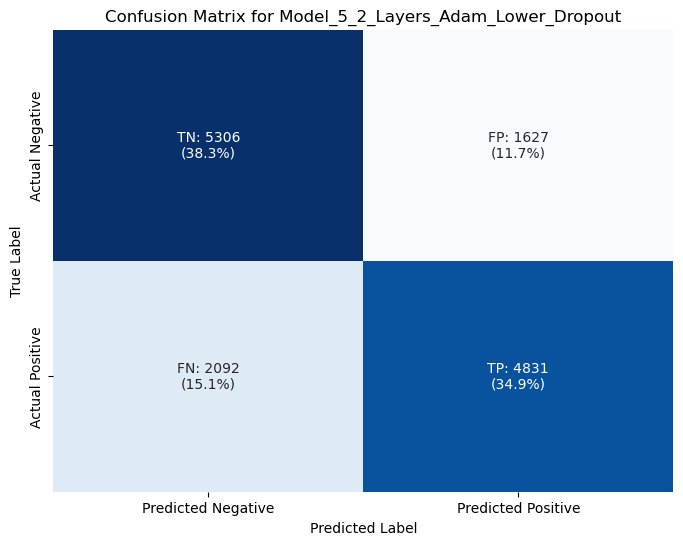


Generating ROC Curve...


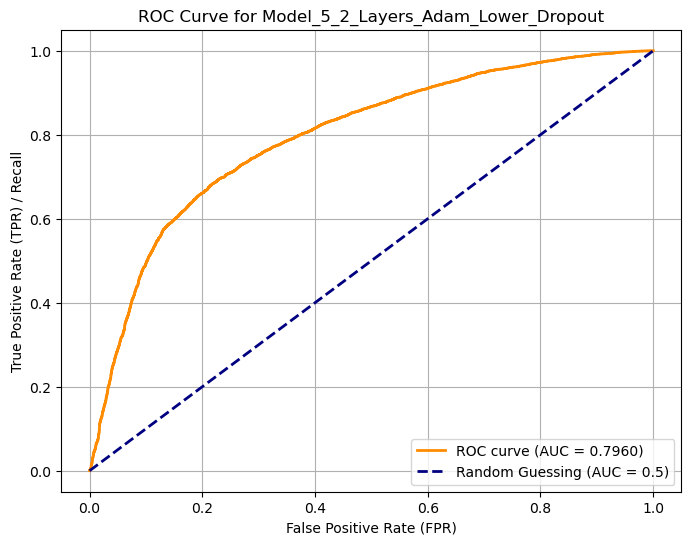

Detailed evaluation complete.

--- Section: Explainability (SHAP) ---
Creating SHAP background data...
Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Computing SHAP values for the first 50 test instances...


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step
1/1 ━━━━━━━


Generating SHAP force plot for the first test instance (Class 1 explanation)...

Generating SHAP summary plot for the first 50 instances (Class 1 explanation)...


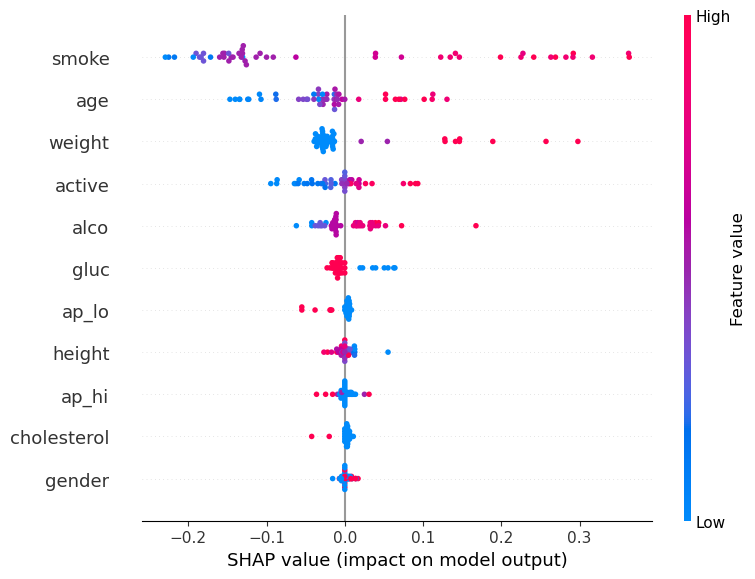


--- Section: Explainability (LIME) ---
Creating LIME explainer...

Generating LIME explanation for the first test instance...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LIME explanation generated (check your environment for plot/list).



LIME Explanation as List:
[('smoke <= -0.24', -0.31934386042676904), ('weight <= -0.54', -0.12807207054684625), ('age <= -0.73', -0.11392277957686897), ('alco <= -0.10', -0.10524554490892327), ('active <= -0.62', -0.08646009525493738)]


In [57]:
# --- Choose a model to perform detailed evaluation and explainability on ---

chosen_model_config_name = 'Model_5_2_Layers_Adam_Lower_Dropout'

# Ensure necessary data and configurations exist
# X_train_scaled_np and X_test_scaled_np are needed for training/evaluation/explainability
# model_configs is needed to retrieve the configuration of the chosen model
# original_feature_names is needed for SHAP/LIME feature labels
if 'X_train_scaled_np' in locals() and X_train_scaled_np is not None and 'model_configs' in locals() and 'original_feature_names' in locals():

    # Find the config dictionary for the chosen model
    chosen_config = next((config for config in model_configs if config['name'] == chosen_model_config_name), None)

    if chosen_config is not None:
        print(f"\n--- Section: Detailed Evaluation and Explainability for '{chosen_model_config_name}' ---")

        # --- Rebuild and Train the Chosen Model ---
        # We need to rebuild and train this specific model again to have the 'model' object available
        # for detailed evaluation plots (like Confusion Matrix) and Explainability (SHAP/LIME).
        # This ensures we are using the weights of THIS specific model configuration.
        print(f"\nRebuilding and training '{chosen_model_config_name}' for detailed analysis...")

        tf.keras.backend.clear_session() # Clear previous models

        model_for_detailed_analysis = Sequential(name=chosen_config['name']) # Use a specific name for this model object

        # --- ADD tf.keras.Input layer as the first layer ---
        model_for_detailed_analysis.add(tf.keras.Input(shape=input_shape))

        # First hidden layer - DO NOT include input_shape here anymore
        model_for_detailed_analysis.add(Dense(units=chosen_config['layer_specs'][0], activation='relu'))
        if chosen_config['dropout_rate'] > 0:
             model_for_detailed_analysis.add(Dropout(chosen_config['dropout_rate']))

        # Additional hidden layers
        for units in chosen_config['layer_specs'][1:]:
            model_for_detailed_analysis.add(Dense(units=units, activation='relu'))
            if chosen_config['dropout_rate'] > 0:
                model_for_detailed_analysis.add(Dropout(chosen_config['dropout_rate']))

        # Output layer
        model_for_detailed_analysis.add(Dense(units=1, activation='sigmoid'))

        # Compile the model
        optimizer_instance = get_optimizer({'class_name': chosen_config['optimizer'], 'config': {'learning_rate': chosen_config['learning_rate']}})
        model_for_detailed_analysis.compile(optimizer=optimizer_instance,
                                      loss='binary_crossentropy',
                                      metrics=['accuracy', Recall(name='recall'), Precision(name='precision')])

        # Train the model with Early Stopping
        early_stopping = EarlyStopping(monitor='val_loss', patience=chosen_config['patience'], restore_best_weights=True)

        print("Starting training for detailed analysis model...")
        history_chosen_model = model_for_detailed_analysis.fit(X_train_scaled_np, y_train, # Use numpy arrays
                                         epochs=chosen_config['epochs'],
                                         batch_size=chosen_config['batch_size'],
                                         validation_data=(X_val_scaled_np, y_val), # Use numpy arrays
                                         callbacks=[early_stopping],
                                         verbose=0) # Set verbose=0 to reduce output

        print(f"Training complete for '{chosen_model_config_name}'.")


        # --- Detailed Evaluation for the Chosen Model ---

        # This section focuses on plotting detailed evaluation visuals.

        print("\nPerforming detailed evaluation (Confusion Matrix, ROC Curve)...")

        # Get predictions and probabilities for the test set using the chosen model
        # Use the numpy array version for prediction
        y_pred_prob_chosen = model_for_detailed_analysis.predict(X_test_scaled_np)
        y_pred_chosen = (y_pred_prob_chosen > 0.5).astype("int32") # Default threshold 0.5

        # Confusion Matrix
        cm_chosen = confusion_matrix(y_test, y_pred_chosen)
        tn, fp, fn, tp = cm_chosen.ravel()

        total_samples = len(y_test)
        tn_percent = tn / total_samples * 100
        fp_percent = fp / total_samples * 100
        fn_percent = fn / total_samples * 100
        tp_percent = tp / total_samples * 100

        annotations = np.array([
            [f"TN: {tn}\n({tn_percent:.1f}%)", f"FP: {fp}\n({fp_percent:.1f}%)"],
            [f"FN: {fn}\n({fn_percent:.1f}%)", f"TP: {tp}\n({tp_percent:.1f}%)"]
        ])

        print("\nGenerating Confusion Matrix...")
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_chosen, annot=annotations, fmt='', cmap='Blues', cbar=False,
                    xticklabels=['Predicted Negative', 'Predicted Positive'],
                    yticklabels=['Actual Negative', 'Actual Positive'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix for {chosen_model_config_name}')
        plt.show()


        # ROC Curve
        print("\nGenerating ROC Curve...")
        # Use the numpy array version for roc_curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_chosen)
        roc_auc = roc_auc_score(y_test, y_pred_prob_chosen)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR) / Recall')
        plt.title(f'ROC Curve for {chosen_model_config_name}')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        print("Detailed evaluation complete.")


        # """## Explainability""" #


        print("\n--- Section: Explainability (SHAP) ---")

        # Ensure SHAP and numpy are imported if not already
        try:
            import shap
        except ImportError:
            print("SHAP library not installed. Skipping SHAP explainability.")
            shap = None # Set shap to None if import fails


        if shap is not None:
            # --- Prepare data and functions for SHAP ---

            # Choose a background dataset (a small sample of training data)
            # SHAP recommends 100-1000 samples for KernelExplainer
            print("Creating SHAP background data...")
            # Use X_train_scaled_np which is the numpy array version
            background_data_shap = shap.sample(X_train_scaled_np, 100) # Use a different variable name to avoid conflict

            # Ensure feature_names is a list (get from original data before scaling)
            # original_feature_names was stored in Data Preprocessing
            feature_names_shap = original_feature_names


            # Wrap the model's prediction function to return probabilities for both classes (shape (n_samples, 2))
            # This function will use the model_for_detailed_analysis object
            def predict_proba_for_shap_detailed(data):
                # Use the specific model object for this section
                # Ensure data is float32 as expected by model.predict
                preds_positive = model_for_detailed_analysis.predict(data.astype(np.float32)) # Shape (n_samples, 1) for sigmoid output
                # Stack probability of class 0 (1-p) and class 1 (p)
                preds_two_columns = np.hstack((1 - preds_positive, preds_positive))
                return np.array(preds_two_columns) # Ensure numpy array output


            # --- Create and run the SHAP explainer ---

            # Create KernelExplainer using the wrapped prediction function and background data
            print("Creating SHAP explainer...")
            try:
                # Pass the predict function specific to the model_for_detailed_analysis object
                explainer = shap.KernelExplainer(predict_proba_for_shap_detailed, background_data_shap)

                # Compute SHAP values for a subset of test instances (e.g., the first 10 or more)
                n_instances_to_explain_shap = 50 # Use a larger number for summary plot if possible
                print(f"Computing SHAP values for the first {n_instances_to_explain_shap} test instances...")
                # Use X_test_scaled_np for computing SHAP values
                # Ensure data is float32 as expected by explainer/model
                shap_values = explainer.shap_values(X_test_scaled_np[:n_instances_to_explain_shap].astype(np.float32))


                print("SHAP values computed.")

                # --- Prepare SHAP values for plotting ---

                # Assuming shap_values is a numpy array of shape (n_instances, n_features, n_outputs) -> (N, 11, 2)
                # We need the SHAP values corresponding to the positive class (Class 1), index 1
                SHAP_values_for_class_1_plot = shap_values[:, :, 1] # Slice all instances, all features, only output 1

                # We also need the base value (expected value) for Class 1, index 1
                # explainer.expected_value is usually an array of shape (n_outputs,) or a list
                base_value_for_class_1_plot = explainer.expected_value[1] # Access the base value for the second output (index 1)

                # --- Visualize SHAP Results ---

                # You can only run shap.initjs() in a Jupyter Notebook or compatible environment
                print("Initializing SHAP JS for notebook display...")
                # Check if in a notebook environment before initializing (optional but good practice)
                try:
                   get_ipython().__class__.__name__
                   shap.initjs()
                except NameError:
                   print("Not in a notebook environment, skipping shap.initjs()")
                # shap.initjs() # Assuming a notebook environment


                # Visualize the explanation for a single prediction (e.g., the first test instance)
                print("\nGenerating SHAP force plot for the first test instance (Class 1 explanation)...")
                try:
                    # Slice SHAP values for the first instance (index 0) for Class 1: SHAP_values_for_class_1_plot[0, :] -> shape (n_features,)
                    # Feature values for the first instance: X_test_scaled_np[0, :] -> shape (n_features,)
                    shap.force_plot(base_value_for_class_1_plot, SHAP_values_for_class_1_plot[0, :], X_test_scaled_np[0, :], feature_names=feature_names_shap)
                except Exception as e:
                    print(f"Could not generate force plot. Error: {e}")
                    print("Ensure the shapes and feature names match.")


                # Visualize the summary of feature importance across multiple instances
                print(f"\nGenerating SHAP summary plot for the first {n_instances_to_explain_shap} instances (Class 1 explanation)...")
                try:
                    # SHAP values for all explained instances for Class 1: SHAP_values_for_class_1_plot -> shape (n_instances, n_features)
                    # Feature values for the same instances: X_test_scaled_np[:n_instances_to_explain_shap] -> shape (n_instances, n_features)
                    shap.summary_plot(SHAP_values_for_class_1_plot, X_test_scaled_np[:n_instances_to_explain_shap], feature_names=feature_names_shap)
                except Exception as e:
                     print(f"Could not generate summary plot. Error: {e}")
                     print("Ensure the shapes and feature names match.")


            except Exception as e:
                 print(f"An error occurred during SHAP calculation or plotting: {e}")
                 print("Please ensure SHAP library is compatible with your TensorFlow version.")
        else:
            print("\nSHAP library not available. Skipping SHAP explainability.")


        # """## LIME"""
        print("\n--- Section: Explainability (LIME) ---")

        # Ensure LIME and numpy are imported if not already
        try:
             import lime
             import lime.lime_tabular
        except ImportError:
            print("LIME library not installed. Skipping LIME explainability.")
            lime = None # Set lime to None if import fails


        if lime is not None:
            try:
                # Create the LIME explainer
                # training_data should be the scaled training data (numpy array)
                # feature_names should be the original feature names (list)
                # class_names should match your target classes (list)
                print("Creating LIME explainer...")
                explainer_lime = lime.lime_tabular.LimeTabularExplainer(
                  training_data=X_train_scaled_np, # Use the numpy array version
                  feature_names=original_feature_names, # Use original feature names list
                  class_names=['No Cardio', 'Cardio'], # Your target class names
                  mode='classification'
                )

                # Define the prediction function for LIME (needs to output probabilities for all classes)
                # predict_proba_for_shap_detailed function already defined above and works for this section
                predict_fn_lime = predict_proba_for_shap_detailed


                # Choose an instance from the scaled test set (numpy array) to explain (e.g., the first test instance)
                instance_to_explain_lime = X_test_scaled_np[0]

                # Get the explanation for the chosen instance
                print("\nGenerating LIME explanation for the first test instance...")
                explanation_lime = explainer_lime.explain_instance(
                    data_row=instance_to_explain_lime,
                    predict_fn=predict_fn_lime, # Use the prediction function specific to this section's model
                    num_features=5 # Number of top features to show in the explanation
                 )

                # Visualize the LIME explanation
                print("LIME explanation generated (check your environment for plot/list).")
                # You can display the plot in a notebook:
                explanation_lime.show_in_notebook()
                # Or print as a list:
                print("\nLIME Explanation as List:")
                print(explanation_lime.as_list())

            except Exception as e:
                print(f"An error occurred during LIME explanation generation: {e}")
                print("Please ensure lime library is installed and you are in a notebook environment for show_in_notebook.")

        else:
            print("\nLIME library not available. Skipping LIME explainability.")


    else:
        print(f"\nSkipping Detailed Evaluation and Explainability as the chosen model '{chosen_model_config_name}' was not found in model_configs.")

else:
    print("\nSkipping Detailed Evaluation and Explainability as data was not loaded/preprocessed.")
